In [ ]:
!pip install google-play-scraper

# Library

In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import re
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud, STOPWORDS

# **Data Preparation**

## **Data Scrapping**

In [ ]:
from google_play_scraper import Sort, reviews

result, continuation_token = reviews(
    'com.apps.MyXL',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=50000,
    filter_score_with=None
)


In [ ]:
data = pd.DataFrame(np.array(result),columns=['review'])
data = data.join(pd.DataFrame(data.pop('review').tolist()))
data.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a9d5203c-93df-4877-aa19-e13d90ba2cc3,Dewa Kiki,https://play-lh.googleusercontent.com/a-/ALV-U...,Good,4,1,None,2023-12-13 05:39:43,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2023-12-11 15:03:09,None
1,09052efb-27e3-495c-905a-4c7e7f869111,Arifuddin Android,https://play-lh.googleusercontent.com/a-/ALV-U...,ok,5,1,None,2023-12-12 10:18:59,"Hi Kak, terima kasih atas kepercayaannya untuk...",2023-12-12 11:00:59,None
2,ef5582f0-7eb3-4262-9354-1dddeae25eb9,Samsung A11,https://play-lh.googleusercontent.com/a/ACg8oc...,Aplikasi lambat,1,3,None,2023-12-11 11:08:26,None,NaT,None
3,374b561b-22fc-442d-aa53-71196464e0c6,Ipan Ipen,https://play-lh.googleusercontent.com/a/ACg8oc...,baik,5,2,5.8.5,2023-12-08 17:26:15,"Hi Kak, terima kasih atas penilaiannya. Penila...",2023-12-08 19:01:28,5.8.5
4,9a1177a1-eaca-42ee-9b29-693a72112650,Gunawan Hendra,https://play-lh.googleusercontent.com/a/ACg8oc...,"Sudah dua hari aplikasinya eror,,,,kenapa yaa",5,11,5.8.6,2023-12-04 07:12:23,None,NaT,5.8.6


In [ ]:
len(data.index) #Jumlah observasi data scrapping

50000

In [ ]:
#Urutkan data dari yang terbaru
new_df = data[['userName', 'score','at', 'content']]
sorted_df = new_df.sort_values(by='at', ascending=False)
sorted_df.head()

,userName,score,at,content
0,Dewa Kiki,4,2023-12-13 05:39:43,Good
1,Arifuddin Android,5,2023-12-12 10:18:59,ok
2,Samsung A11,1,2023-12-11 11:08:26,Aplikasi lambat
3,Ipan Ipen,5,2023-12-08 17:26:15,baik
4,Gunawan Hendra,5,2023-12-04 07:12:23,"Sudah dua hari aplikasinya eror,,,,kenapa yaa"


In [ ]:
my_df = sorted_df[['userName', 'score','at', 'content']]
#Ganti tipe data 'at'
my_df['at'] = pd.to_datetime(my_df['at'])
my_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   userName  50000 non-null  object        
 1   score     50000 non-null  int64         
 2   at        50000 non-null  datetime64[ns]
 3   content   50000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.9+ MB


In [ ]:
#Ulasan untuk tahun 2023
start_date = '2023-01-01 00:00:00'
end_date = '2023-10-31 23:59:00'
my_df = my_df[(my_df['at'] >= start_date) & (my_df['at'] <= end_date)]
my_df

,userName,score,at,content
19365,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...
19366,doni firman,5,2023-10-31 23:52:26,nice
19367,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah
19368,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin
19369,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku
...,...,...,...,...
49995,Pak Ahmad,5,2023-08-29 05:31:05,ok
49996,Sodikin Linda,1,2023-08-29 05:29:14,Saya suka
49997,Intan Tan,5,2023-08-29 05:28:32,mantap
49998,Riko Prasandi,1,2023-08-29 05:27:34,Kemana pulsa ku diisi 100 RB tanggal 28 Agustus


## **Pelabelan**

In [ ]:
def pelabelan(score):
  if score <= 3:
    return 'Negatif'
  elif score >= 3 :
    return 'Positif'
my_df['Label'] = my_df ['score'].apply(pelabelan)
my_df.head(50)

,userName,score,at,content,Label
19365,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...,Negatif
19366,doni firman,5,2023-10-31 23:52:26,nice,Positif
19367,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah,Positif
19368,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin,Negatif
19369,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku,Positif
19370,Damaraku Mau Lagi,3,2023-10-31 23:38:53,XL ayo lah jangan gini ga kayak dulu fast resp...,Negatif
19371,Ika Fanny,5,2023-10-31 23:35:17,"Banyakin donk untuk promonya ,🥰",Positif
19372,Saepul Nurjaman,5,2023-10-31 23:32:00,mantap,Positif
19373,Ali Santoso,5,2023-10-31 23:18:17,sangat bermanfaat,Positif
19374,Royan Bayu,1,2023-10-31 23:08:54,Sinyal nya kenapa ga stabil ya padahal 4G,Negatif


In [ ]:
my_df.to_csv("datascrap.csv", index = False)  #Save file as CSV

## **Data Prepocesing**
data cleaning

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
my_df = pd.read_csv('/content/datascrap.csv')
my_df.head(5)

,userName,score,at,content,Label
0,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...,Negatif
1,doni firman,5,2023-10-31 23:52:26,nice,Positif
2,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah,Positif
3,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin,Negatif
4,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku,Positif


In [ ]:
my_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30635 entries, 0 to 30634
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  30635 non-null  object
 1   score     30635 non-null  int64 
 2   at        30635 non-null  object
 3   content   30635 non-null  object
 4   Label     30635 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.2+ MB


In [ ]:
#pemeriksaan data missing
my_df.isna().any()

userName    False
score       False
at          False
content     False
Label       False
dtype: bool

In [ ]:
my_df.describe()

,score
count,30635.000000
mean,2.908830
std,1.795826
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,5.000000


In [ ]:
#Pemeriksaan data missing
my_df.isnull().sum()

userName    0
score       0
at          0
content     0
Label       0
dtype: int64

1. Handling Missing value-Ignore tuple

In [ ]:
my_df.dropna(subset=['Label'],inplace = True)

In [ ]:
my_df.isnull().sum()

userName    0
score       0
at          0
content     0
Label       0
dtype: int64

In [ ]:
my_df.head(5)

,userName,score,at,content,Label
0,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...,Negatif
1,doni firman,5,2023-10-31 23:52:26,nice,Positif
2,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah,Positif
3,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin,Negatif
4,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku,Positif


In [ ]:
my_df.to_csv("MyXLpreprocessing.csv", index = False)

## **Text PreProcessing**

In [ ]:
df = pd.read_csv('/content/MyXLpreprocessing.csv')
df.head(5)

,userName,score,at,content,Label
0,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...,Negatif
1,doni firman,5,2023-10-31 23:52:26,nice,Positif
2,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah,Positif
3,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin,Negatif
4,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku,Positif


### **Case Folding**
Proses case folding adalah proses mengubah seluruh huruf menjadi huruf kecil. Pada proses ini karakter-karakter 'A'-'Z' yang terdapat pada data diubah kedalam karakter 'a'-'z'.

In [ ]:
def  clean_text(df, text_field, new_text_field_name):
    my_df[new_text_field_name] = my_df[text_field].str.lower()
    my_df[new_text_field_name] = my_df[new_text_field_name].apply(lambda elem: re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.+?", "", elem))
    # remove numbers
    my_df[new_text_field_name] = my_df[new_text_field_name].apply(lambda elem: re.sub(r"\d+", "", elem))
    return my_df

In [ ]:
my_df['text_clean'] = my_df['content'].str.lower()
my_df['text_clean']
data_clean = clean_text(my_df, 'content', 'text_clean')
data_clean.head(10)

,userName,score,at,content,Label,text_clean
0,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...,Negatif,mau aktifin voucher harus download aplikasi in...
1,doni firman,5,2023-10-31 23:52:26,nice,Positif,nice
2,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah,Positif,harganya tergolong murah
3,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin,Negatif,lumayan cepat peros nyag kaya kemarinkemarin
4,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku,Positif,bagus sih gak ada kendala menurut ku
5,Damaraku Mau Lagi,3,2023-10-31 23:38:53,XL ayo lah jangan gini ga kayak dulu fast resp...,Negatif,xl ayo lah jangan gini ga kayak dulu fast resp...
6,Ika Fanny,5,2023-10-31 23:35:17,"Banyakin donk untuk promonya ,🥰",Positif,banyakin donk untuk promonya
7,Saepul Nurjaman,5,2023-10-31 23:32:00,mantap,Positif,mantap
8,Ali Santoso,5,2023-10-31 23:18:17,sangat bermanfaat,Positif,sangat bermanfaat
9,Royan Bayu,1,2023-10-31 23:08:54,Sinyal nya kenapa ga stabil ya padahal 4G,Negatif,sinyal nya kenapa ga stabil ya padahal g


### **Stopword Removal**
Stopword adalah kata umum yang biasanya muncul dalam jumlah besar dan dianggap tidak memiliki makna. Contoh stopword dalam bahasa Indonesia adalah “yang”, “dan”, “di”, “dari”, dll. Makna di balik penggunaan stopword yaitu dengan menghapus kata-kata yang memiliki informasi rendah dari sebuah teks, kita dapat fokus pada kata-kata penting sebagai gantinya.

In [ ]:
import nltk.corpus
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('indonesian')
data_clean['text_StopWord'] = data_clean['text_clean'].apply(lambda x:' '.join([word for word in x.split() if word not in (stop)]))
data_clean.head(50)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,userName,score,at,content,Label,text_clean,text_StopWord
0,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...,Negatif,mau aktifin voucher harus download aplikasi in...,aktifin voucher download aplikasi karna ganggu...
1,doni firman,5,2023-10-31 23:52:26,nice,Positif,nice,nice
2,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah,Positif,harganya tergolong murah,harganya tergolong murah
3,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin,Negatif,lumayan cepat peros nyag kaya kemarinkemarin,lumayan cepat peros nyag kaya kemarinkemarin
4,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku,Positif,bagus sih gak ada kendala menurut ku,bagus sih gak kendala ku
5,Damaraku Mau Lagi,3,2023-10-31 23:38:53,XL ayo lah jangan gini ga kayak dulu fast resp...,Negatif,xl ayo lah jangan gini ga kayak dulu fast resp...,xl ayo gini ga kayak fast respon lemotlow resp...
6,Ika Fanny,5,2023-10-31 23:35:17,"Banyakin donk untuk promonya ,🥰",Positif,banyakin donk untuk promonya,banyakin donk promonya
7,Saepul Nurjaman,5,2023-10-31 23:32:00,mantap,Positif,mantap,mantap
8,Ali Santoso,5,2023-10-31 23:18:17,sangat bermanfaat,Positif,sangat bermanfaat,bermanfaat
9,Royan Bayu,1,2023-10-31 23:08:54,Sinyal nya kenapa ga stabil ya padahal 4G,Negatif,sinyal nya kenapa ga stabil ya padahal g,sinyal nya ga stabil ya g


### Normalisasi Kata

### **Tokenizing**
Tokenizing adalah proses pemisahan teks menjadi potongan-potongan yang disebut sebagai token untuk kemudian di analisa. Kata, angka, simbol, tanda baca dan entitas penting lainnya dapat dianggap sebagai token. Didalam NLP, token diartikan sebagai “kata” meskipun tokenize juga dapat dilakukan pada paragraf maupun kalimat

In [ ]:
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize, word_tokenize
data_clean['text_tokens'] = data_clean['text_StopWord'].apply(lambda x: word_tokenize(x))
data_clean.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,userName,score,at,content,Label,text_clean,text_StopWord,text_tokens
0,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...,Negatif,mau aktifin voucher harus download aplikasi in...,aktifin voucher download aplikasi karna ganggu...,"[aktifin, voucher, download, aplikasi, karna, ..."
1,doni firman,5,2023-10-31 23:52:26,nice,Positif,nice,nice,[nice]
2,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah,Positif,harganya tergolong murah,harganya tergolong murah,"[harganya, tergolong, murah]"
3,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin,Negatif,lumayan cepat peros nyag kaya kemarinkemarin,lumayan cepat peros nyag kaya kemarinkemarin,"[lumayan, cepat, peros, nyag, kaya, kemarinkem..."
4,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku,Positif,bagus sih gak ada kendala menurut ku,bagus sih gak kendala ku,"[bagus, sih, gak, kendala, ku]"


### **Stemming**
Stemming adalah proses pemetaan dan penguraian bentuk dari suatu kata menjadi bentuk kata dasarnya. Untuk melakukan stemming bahasa Indonesia kita dapat menggunakan library Python Sastrawi yang sudah kita siapkan di awal. Library Sastrawi menerapkan Algoritma Nazief dan Adriani dalam melakukan stemming bahasa Indonesia.

In [ ]:
!pip install Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.0 MB/s eta 0:00:00


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [ ]:
#-----------------STEMMING -----------------
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
#import swifter


# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemmed
def stemmed_wrapper(term):
    return stemmer.stem(term)

term_dict = {}
hitung=0

for document in data_clean['text_tokens']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '
print(len(term_dict))
print("------------------------")
for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    hitung+=1
    print(hitung,":",term,":" ,term_dict[term])

print(term_dict)
print("------------------------")

# apply stemmed term to dataframe
def get_stemmed_term(document):
    return [term_dict[term] for term in document]


#script ini bisa dipisah dari eksekusinya setelah pembacaaan term selesai
data_clean['text_steamindo'] = data_clean['text_tokens'].apply(lambda x:' '.join(get_stemmed_term(x)))
data_clean.head(5)

Streaming output truncated to the last 5000 lines.
12590 : peketa : keta
12591 : titak : titak
12592 : peroanjang : peroanjang
12593 : galgal : galgal
12594 : muantul : muantul
12595 : berubahjelek : berubahjelek
12596 : hl : hl
12597 : penyedit : penyedit
12598 : jelaasss : jelaasss
12599 : gjlssss : gjlssss
12600 : asliiiii : asliiiii
12601 : direport : direport
12602 : jarung : jarung
12603 : bengt : bengt
12604 : habiiisssssss : habiiisssssss
12605 : pakettt : pakettt
12606 : terimakasiii : terimakasiii
12607 : hilangsaran : hilangsaran
12608 : pulsaya : pulsaya
12609 : yesel : yesel
12610 : signifikan : signifikan
12611 : kpn : kpn
12612 : kemajuannya : maju
12613 : teranjing : anjing
12614 : sumpahin : sumpahin
12615 : kesambar : sambar
12616 : fikirkan : fikirkan
12617 : bacotttt : bacotttt
12618 : gqk : gqk
12619 : tolsng : tolsng
12620 : malesan : malesan
12621 : ningkatin : ningkatin
12622 : bosokdi : bosokdi
12623 : pembaeritahuan : pembaeritahuan
12624 : trusbsi : trusbsi
1

,userName,score,at,content,Label,text_clean,text_StopWord,text_tokens,text_steamindo
0,Frank Armstrong 13,1,2023-10-31 23:54:33,Mau aktifin voucher harus download aplikasi in...,Negatif,mau aktifin voucher harus download aplikasi in...,aktifin voucher download aplikasi karna ganggu...,"[aktifin, voucher, download, aplikasi, karna, ...",aktifin voucher download aplikasi karna ganggu...
1,doni firman,5,2023-10-31 23:52:26,nice,Positif,nice,nice,[nice],nice
2,Galih Apriyanto,5,2023-10-31 23:49:55,harganya tergolong murah,Positif,harganya tergolong murah,harganya tergolong murah,"[harganya, tergolong, murah]",harga golong murah
3,Haikal 123,3,2023-10-31 23:41:33,lumayan cepat peros nya...g kaya kemarin-kemarin,Negatif,lumayan cepat peros nyag kaya kemarinkemarin,lumayan cepat peros nyag kaya kemarinkemarin,"[lumayan, cepat, peros, nyag, kaya, kemarinkem...",lumayan cepat ros nyag kaya kemarinkemarin
4,Marojal Bahraen yaltaqian,5,2023-10-31 23:41:27,Bagus sih gak ada kendala menurut ku,Positif,bagus sih gak ada kendala menurut ku,bagus sih gak kendala ku,"[bagus, sih, gak, kendala, ku]",bagus sih gak kendala ku


In [ ]:
data_clean.to_csv('hasil_TextPreProcessing_MyXL.csv', index=False)

In [ ]:
import re
def praproses(text):
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall('(?::|;|=)()(?:-)?(?:\)|\(|D|P)',
                           text)
    text = (re.sub('[\W]+', ' ', text.lower()) +
            ' '.join(emoticons).replace('-', ''))
    return text

### **Proporsi Label**

Counter({'Negatif': 17123, 'Positif': 13512})


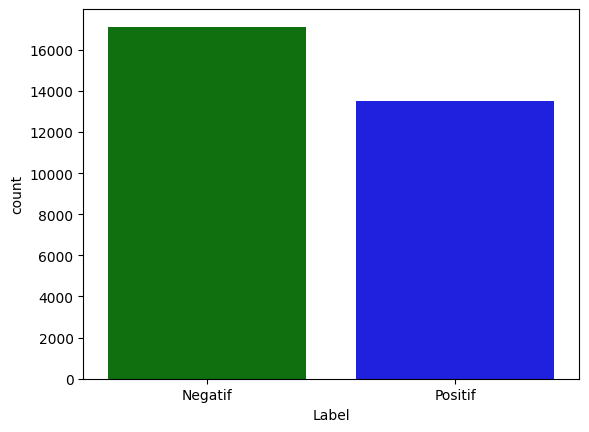

In [ ]:
x = data_clean.text_steamindo
y = data_clean.Label

print(Counter(y))
sns.countplot(x=y,palette=['green', 'blue'])
plt.show()

# **Word Cloud**

In [ ]:
Positif= " ".join(review for review in data_clean[data_clean['Label'] == 'Positif'].text_steamindo)
Negatif= " ".join(review for review in data_clean[data_clean['Label'] == 'Negatif'].text_steamindo)
stopwords = set(STOPWORDS)
def plot_cloud(wordcloud):
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud)
    plt.axis("off");

## **Wordcloud label posiif**

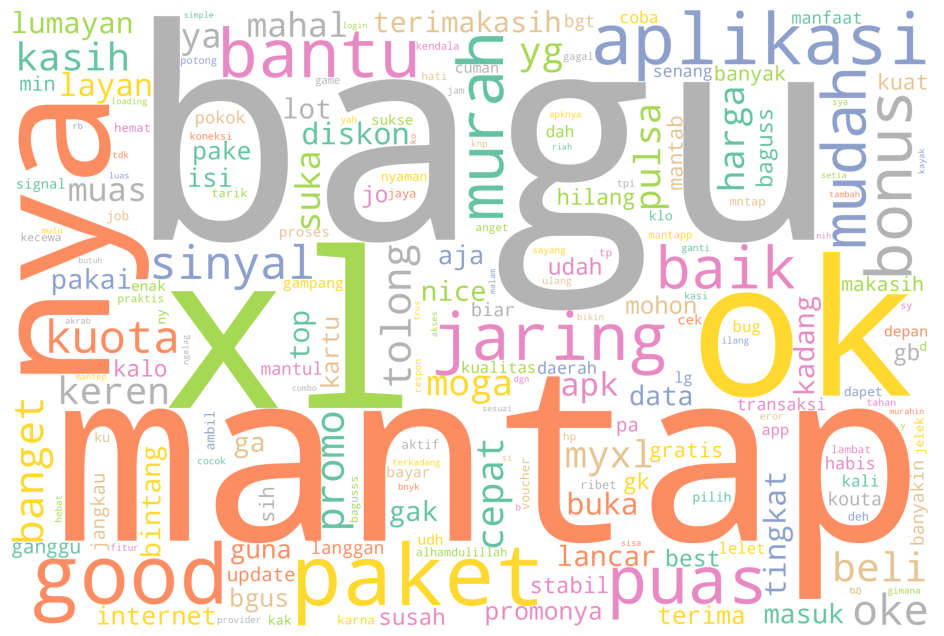

In [ ]:
wordcloud1 = WordCloud(width = 3000, height = 2000, random_state=3, background_color='white', colormap='Set2', collocations=False, stopwords = STOPWORDS).generate(Positif)
plot_cloud(wordcloud1)

## *Wordcloud Label Negatif*

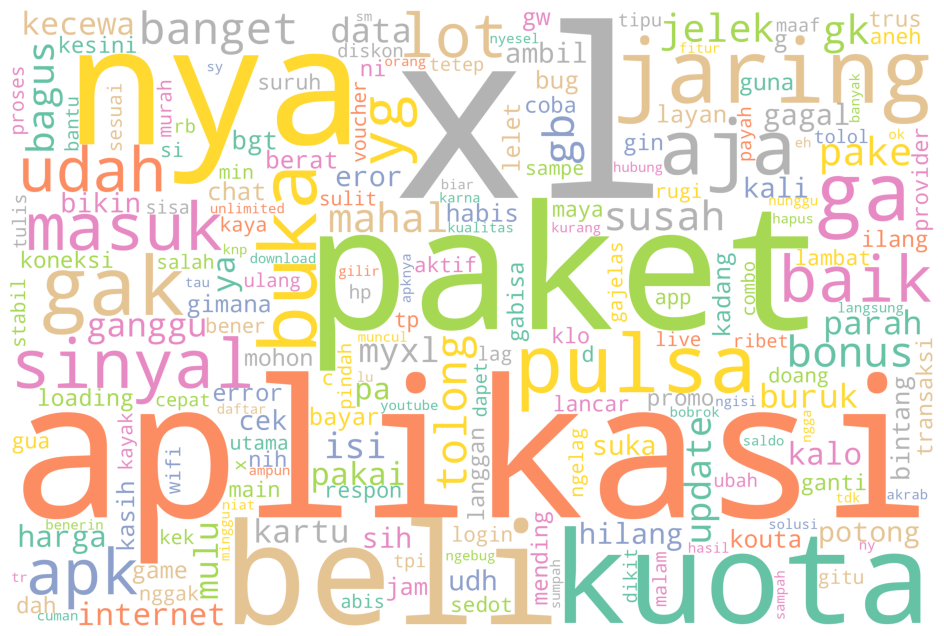

In [ ]:
wordcloud1 = WordCloud(width = 3000, height = 2000, random_state=3, background_color='white', colormap='Set2', collocations=False, stopwords = STOPWORDS).generate(Negatif)
plot_cloud(wordcloud1)

# **ANALISIS SENTIMEN**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data_clean['content'], data_clean['Label'],
                                                    test_size = 0.20,
                                                    random_state = 0)

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(24508,)
(24508,)
(6127,)
(6127,)


In [ ]:
vectorizer = CountVectorizer()
vectorizer.fit(X_train)

CountVectorizer()

In [ ]:
X_train = vectorizer.transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
nb = MultinomialNB()
nb.fit(tfidf_train, y_train)

MultinomialNB()

In [ ]:
X_train.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
y_pred = nb.predict(tfidf_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8566998531091888

In [ ]:
clf = MultinomialNB()
clf.fit(X_train, y_train)
predicted = clf.predict(X_test)

print("MultinomialNB Accuracy:", accuracy_score(y_test,predicted))
print("MultinomialNB Precision:", precision_score(y_test,predicted, average="binary", pos_label="Negatif"))
print("MultinomialNB Recall:", recall_score(y_test,predicted, average="binary", pos_label="Negatif"))
print("MultinomialNB f1_score:", f1_score(y_test,predicted, average="binary", pos_label="Negatif"))

print(f'confusion_matrix:\n {confusion_matrix(y_test, predicted)}')
print('====================================================\n')
print(classification_report(y_test, predicted, zero_division=0))

# Load dataset
data_clean = pd.read_csv('hasil_TextPreProcessing_MyXL.csv')

MultinomialNB Accuracy: 0.8674718459278603
MultinomialNB Precision: 0.8637510513036165
MultinomialNB Recall: 0.9043146463164073
MultinomialNB f1_score: 0.8835675365643819
confusion_matrix:
 [[3081  326]
 [ 486 2234]]

              precision    recall  f1-score   support

     Negatif       0.86      0.90      0.88      3407
     Positif       0.87      0.82      0.85      2720

    accuracy                           0.87      6127
   macro avg       0.87      0.86      0.86      6127
weighted avg       0.87      0.87      0.87      6127

